In [43]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d
import matplotlib.cm as cm
import sklearn

import TP4_helper_function_dont_look

Crédit TP : François Landes

### Exécutez les cellules ci dessous (rien d'autre à faire)


In [44]:
def plot_data(X, y):
    plt.figure(figsize=[5,5]) ## equal x and y lengths for a squared figure
    plt.scatter(X[:, 0], X[:, 1], c=y, s = 100, alpha = 0.7)
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    #plt.legend()

In [45]:
X, yregress, yclassif = TP4_helper_function_dont_look.getData(42)
X_test, yregress_test, yclassif_test = TP4_helper_function_dont_look.getData(41, 1000)

# Part 1 : classification du dataset XOR

Nous allons coder notre propre feature map pour classer le dataset XOR. 

Ce TP sera aussi une première introduction à la bibliothèque *sklearn* contenant tous les modèles principaux de ML (et davantage)

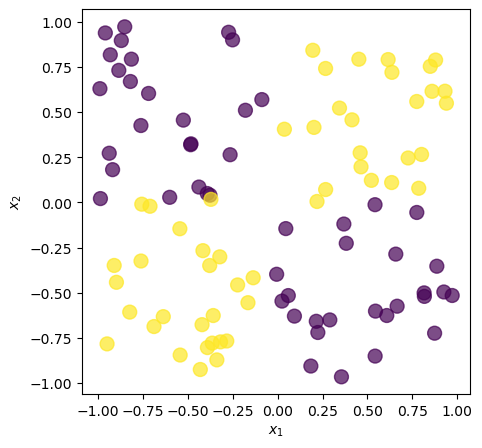

In [46]:
plot_data(X, yclassif)

In [47]:
## feature map, par défaut, la fonction identité
def defaultFeatureMap(X):
    return X

In [48]:
## Une fonction pour plot les frontières de décision pour la classifiation
## L'idée est simplement d'appliquer le classificateur à un grand nombre de points répartis en grille
## Puis de plot en une certaine couleur la zone autour du point suivant le résultat du  classificateur
def plot_boundary(clf, X, y, featureMap=None):
    if featureMap == None:
        featureMap = defaultFeatureMap
    x_min, x_max = X[:, 0].min() - .1, X[:, 0].max() + .1 
    y_min, y_max = X[:, 1].min() - .1, X[:, 1].max() + .1
    hx = hy = 0.002 ## grid mesh size
    hx = (x_max-x_min)/200 ## grid mesh size
    hy = (y_max-y_min)/200 ## grid mesh size
    xx, yy = np.meshgrid(np.arange(x_min, x_max, hx),
                         np.arange(y_min, y_max, hy))
    Z = clf.predict(featureMap(np.c_[xx.ravel(), yy.ravel()])) ## prediction value by zone
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=[5,5]) ## equal x and y lengths for a squared figure
    plt.title('score : ' + str(clf.score(featureMap(X),y)))    
    plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, s = 10)
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.legend()

### Perceptron avec *sklearn*

Pour savoir comment se servir d'une fonction avec *sklearn*, la doc est très complète, par exemple pour le perceptron :

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Perceptron.html

In [49]:
## On peut aussi obtenir la doc ainsi :
?sklearn.linear_model.Perceptron

Init signature:
sklearn.linear_model.Perceptron(
    *,
    penalty=None,
    alpha=0.0001,
    l1_ratio=0.15,
    fit_intercept=True,
    max_iter=1000,
    tol=0.001,
    shuffle=True,
    verbose=0,
    eta0=1.0,
    n_jobs=None,
    random_state=0,
    early_stopping=False,
    validation_fraction=0.1,
    n_iter_no_change=5,
    class_weight=None,
    warm_start=False,
)
Docstring:     
Linear perceptron classifier.

The implementation is a wrapper around :class:`~sklearn.linear_model.SGDClassifier`
by fixing the `loss` and `learning_rate` parameters as::

    SGDClassifier(loss="perceptron", learning_rate="constant")

Other available parameters are described below and are forwarded to
:class:`~sklearn.linear_model.SGDClassifier`.

Read more in the :ref:`User Guide <perceptron>`.

Parameters
----------

penalty : {'l2','l1','elasticnet'}, default=None
    The penalty (aka regularization term) to be used.

alpha : float, default=0.0001
    Constant that multiplies the regularizatio

In [50]:
clf = #TODO On attribut à clf un objet Perceptron.  clf est alors un percetron, mais qui n'a pas été entrainé.
#TODO On entraine le perceptron avec nos données X et yclassif. (utilisez la fonction .fit() )
#TODO Observer les performances de notre modèle. (utilisez la fonction .score() )

SyntaxError: invalid syntax (2913976604.py, line 1)

In [ ]:
plot_boundary(clf, X, yclassif)

## Question 1.2 : 

Êtes vous sastifait de la classification ?

Comment peut on l'améliorer ?

### Réponse : 


## Question 1.3 : votre feature map ! 

- Définissez votre propre feature map. Vous pouvez utiliser une feature map polynomial ou même n'ajouter qu'une seule dimension.
- Créez un nouveau vecteur $X_f = \phi(X)$, i.e. transformez votre dataset grâce à cette feature map.
- Utilisez ces données transformées en input de votre classificateur **linéaire** (perceptron).
- Regardez le score et affichez la frontière de décision avec plot_boundary()

Note : Vous êtes libre d'écrire la fonction featureMap comme vous le souhaitez, mais n'hésitez pas à utiliser les fonctions de numpy, telles que np.column_stack(). C'est aussi une bonne occasion d'apprendre à se familiariser avec.

In [ ]:
def featureMap(X):
    return #TODO

### Vérifiez la shape de vos données après transformation.
Si vous n'avez rien changé, $X$ est de dimension (100,2) donc $X_f$ doit être de dimension (100,D') avec D'>2 et dépendant de la feature map que vous avez écrite.

In [ ]:
X_f = featureMap(X)
X_f.shape

In [ ]:
clf2 = #TODO On attribut à clf un objet Perceptron.  clf est alors un percetron, mais qui n'a pas été entrainé.
#TODO On entraine le perceptron avec nos données X_f (!) et yclassif. (utilisez la fonction .fit() )
#TODO Observer les performances de notre modèle. (utilisez la fonction .score() )??

SyntaxError: invalid syntax (1564976494.py, line 1)

In [ ]:
plot_boundary(clf2, X, yclassif, featureMap)

## Question 1.4 : 
Êtes vous sastifait de la classification ? Est ce mieux que sans feature map ?


## Réponse : 


## Question 1.5: 
Calculez le score pour le test set

Rappel les variables sont : X_test, yclassif_test

In [ ]:
plot_boundary(clf2, X_test, yclassif_test, featureMap)

## Question 1.6:

Créez la *learning curve* du problème.

Vous pouvez choisir un nombre une croissance exponentielle pour la taille des vos données d'entrainement, par exemple : `Ntrains = [10,30,100,300,1000, 3000, 10000]`, ou `Ntrains = [2**k for k in range(10)]`et un nombre de examples test similaires.


In [ ]:
Ntrains = [2**k for k in range(1,10)]

clf2 = #TODO nouvel objet Perceptron
score_train =[]
score_test  =[]
for Ntrain in Ntrains:
    X, yregress, yclassif = TP4_helper_function_dont_look.getData(42, Ntrain) # Pas besoin d'utiliser yregress ici
    #TODO générer test set, entrainer sur train, calculer et stocker le score sur train et test...

SyntaxError: invalid syntax (1377825654.py, line 3)

In [ ]:
plt.semilogx(??)

plt.figure()


# Part 2: same thing but with regression ! (Bonus)

Now we re-do the same thing but for a regression task.
The data is `X, yregress`

In [ ]:

import TP4_helper_function_dont_look
X, yregress, yclassif = TP4_helper_function_dont_look.getData(42)
X_test, yregress_test, yclassif_test = TP4_helper_function_dont_look.getData(41, 1000)

In [ ]:
X[:5,:], yregress[:5]

In [ ]:
def twod_scatter_plot_colored_value(X, y):
    plt.scatter(X[:,0], X[:,1], s=10, c=y, cmap='jet')
    plt.colorbar()

In [ ]:
twod_scatter_plot_colored_value(X, yregress)

In [ ]:
## another way to plot, less legible in my opinion
fig = plt.figure()
ax = plt.axes(projection="3d")
#Labeling
ax.set_xlabel('X Axes')
ax.set_ylabel('Y Axes')
ax.set_zlabel('Z Axes')
ax.plot3D(X[:,0], X[:,1], yregress, ls='', marker='o')
plt.show()

## Question 2.1 : code your regressor !

define a class `classLinearRegressorFullBatch`  that will perform regression, in a similar fashion as `classLinearClassifierFullBatch` did perform a (binary) classification.
There should be only 2,3 or 4 lines at most to change.

Remember:
- the model and cost function are essentially (or exactly?) the same
- the prediction now takes in values in $\mathbb{R}$
- the score is now defined not as the number of correctly classified points, but as the Mean Squared Error. In other terms, it's essentially equal to the Loss.

In [ ]:
def plot_prediction_regress(reg, X, y, featureMap=None):  
    if featureMap == None:
        featureMap = defaultFeatureMap
    h = 0.02 ## grid mesh size
    x_min, x_max = X[:, 0].min() - .1, X[:, 0].max() + .1 
    y_min, y_max = X[:, 1].min() - .1, X[:, 1].max() + .1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    fig = plt.figure()
    Z = reg.predict(featureMap(np.c_[xx.ravel(), yy.ravel()])) ## prediction value by zone
    Z = Z.reshape(xx.shape)
    plt.contourf(xx,yy,Z)
    plt.colorbar()
    twod_scatter_plot_colored_value(X, y)


In [ ]:
#
#the other kind of plot 
def plot_prediction_regress_2(reg, X, y, featureMap=None):  
    if featureMap == None:
        featureMap = defaultFeatureMap
    h = 0.02 ## grid mesh size
    x_min, x_max = X[:, 0].min() - .1, X[:, 0].max() + .1 
    y_min, y_max = X[:, 1].min() - .1, X[:, 1].max() + .1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    fig = plt.figure()
    ax = plt.axes(projection="3d")
    Z = reg.predict(featureMap(np.c_[xx.ravel(), yy.ravel()])) ## prediction value by zone
    Z = Z.reshape(xx.shape)
    plt.title('score : ' + str(reg.score(featureMap(X),y)))  
    ax.plot3D(xx.flatten(), yy.flatten(), Z.flatten(),marker='o', ls='',color="green")
    ax.scatter(X[:, 0], X[:, 1], y, c=y, s = 100)
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.legend()

In [ ]:
class classLinearRegressorFullBatch():

    def __init__(self, eta=0.001, maxIter=100, seed=42, verbose=True, fit_intercept=True):
        self.eta = eta
        self.maxIter = maxIter
        self.seed = seed
        self.w = None # at the start, it's undefined
        self.fit_intercept = fit_intercept
        self.verbose = verbose
        
    def initializeWeights(self,D):
        pass
    
    def fit(self, Xraw, y):
        pass
    
    def predict(self,Xraw):
        return ??
    
    def score(self, X, y):
        return ??
        

### Now, run it

In [ ]:
reg1 = classLinearRegressorFullBatch(eta=0.01, seed=42, maxIter=3000) # order of parameters does not matter
??

In [ ]:
plot_prediction_regress(reg1, X, yregress)

## Question 2.2: does it work well ? why ?

## Answer: 


## Question 2.3

- As before, use a trick to make your LINEAR algorithm become really good.
- plot the predictions and data using the function `plot_prediction_regress()`
- are you happy now ? 

In [ ]:
reg2 = classLinearRegressorFullBatch(eta=0.01, seed=42, maxIter=30000) # order of parameters does not matter
??

In [ ]:
plot_prediction_regress(reg2, X, yregress, featureMap)

## Quesiton 2.4

Compute also the test error and plot the prediction on the test data

(in this case it's not very instructive, but it's a good habit to take)

In [ ]:
plot_prediction_regress(reg2, X_test, yregress_test, featureMap)

## Question 2.5:

build the *learning curve* of the problem.

You may choose an exponentially growing number of training examples, such as `Ntrains = [2**k for k in range(10)]`, and a large number of test examples, for the sake of having a precise estimation of the test error. You should probably use log-log or semilog- plots.
    

In [ ]:

Ntrains = [2**k for k in range(10)]

# Note:

If you run the code below (**Part 3**) and want to play again with your code above this point, you should re-load the part 1&2 data !


In [ ]:
X, yregress, yclassif = TP4_helper_function_dont_look.getData(42)
X_test, yregress_test, yclassif_test = TP4_helper_function_dont_look.getData(41, 1000)

# Part 3 : the moon data set

The so-called moons data set can be generated with sklearn:

In [ ]:
from sklearn.datasets import make_moons
data = make_moons(noise = 0.1, random_state=1, n_samples=400)

In [ ]:
data

## Question 3.1: solve the task

- On your own, identify which kind of task is at hand:
    - what kind of data is it ?
    - is it supervised, unsupervised ? Which sub-class of ML is it ?
    - is the data in the form you need (label values taking the expected kind of values for instance) ? Is it well standardized ?
- Using a simple (linear) model that you already have from previous work, try to solve the task.
- are you satisfied with the result ? What can we do ? 
- you may need to use a slightly more complicated feature map than before

## Answers to 3.1: 



# Part 4 : pen-and-paper exercise, to do at home

This is to get a bit of practice with mathematics and understand the violence of polynomials

- Take a piece of paper and compute $(1+\vec{x}\cdot\vec{x}')^2$, but for $D=3$, and try to write down the corresponding $\phi(\vec{x})$. Do it also for $D=4$.
- Take a piece of paper and compute $(1+\vec{x}\cdot\vec{x}')^3$, but for $D=2$, and try to write down the corresponding $\phi(\vec{x})$. 
